In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

In [14]:
df = pd.read_csv(r"C:\Users\Dell\Downloads\retail_sales_dataset.csv")

In [15]:
df.head()

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100


In [16]:
df.tail()

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
995,996,2023-05-16,CUST996,Male,62,Clothing,1,50,50
996,997,2023-11-17,CUST997,Male,52,Beauty,3,30,90
997,998,2023-10-29,CUST998,Female,23,Beauty,4,25,100
998,999,2023-12-05,CUST999,Female,36,Electronics,3,50,150
999,1000,2023-04-12,CUST1000,Male,47,Electronics,4,30,120


In [17]:
df.shape

(1000, 9)

In [18]:
df.columns

Index(['Transaction ID', 'Date', 'Customer ID', 'Gender', 'Age',
       'Product Category', 'Quantity', 'Price per Unit', 'Total Amount'],
      dtype='str')

In [19]:
df.isnull().sum()

Transaction ID      0
Date                0
Customer ID         0
Gender              0
Age                 0
Product Category    0
Quantity            0
Price per Unit      0
Total Amount        0
dtype: int64

In [20]:
df.drop_duplicates(inplace=True)

In [21]:
df.duplicated().sum()

np.int64(0)

In [22]:
df.dtypes

Transaction ID      int64
Date                  str
Customer ID           str
Gender                str
Age                 int64
Product Category      str
Quantity            int64
Price per Unit      int64
Total Amount        int64
dtype: object

In [23]:
print("Gender:", df['Gender'].unique())
print("Product Categories:", df['Product Category'].unique())

Gender: <StringArray>
['Male', 'Female']
Length: 2, dtype: str
Product Categories: <StringArray>
['Beauty', 'Clothing', 'Electronics']
Length: 3, dtype: str


In [24]:
df.describe()

,Transaction ID,Age,Quantity,Price per Unit,Total Amount
count,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000
mean,500.500000,41.39200,2.514000,179.890000,456.000000
std,288.819436,13.68143,1.132734,189.681356,559.997632
min,1.000000,18.00000,1.000000,25.000000,25.000000
25%,250.750000,29.00000,1.000000,30.000000,60.000000
50%,500.500000,42.00000,3.000000,50.000000,135.000000
75%,750.250000,53.00000,4.000000,300.000000,900.000000
max,1000.000000,64.00000,4.000000,500.000000,2000.000000


In [25]:
print("Total Revenue:", df['Total Amount'].sum())
print("Total Quantity Sold:", df['Quantity'].sum())
print("Total Transactions:", df['Transaction ID'].nunique())
print("Unique Customers:", df['Customer ID'].nunique())
print("Average Transaction Value:", df['Total Amount'].mean())

Total Revenue: 456000
Total Quantity Sold: 2514
Total Transactions: 1000
Unique Customers: 1000
Average Transaction Value: 456.0


In [27]:
df['Date'] = pd.to_datetime(df['Date'])

In [28]:
df['Date'].dtype

dtype('<M8[us]')

In [29]:
df['Month'] = df['Date'].dt.month
df['Month Name'] = df['Date'].dt.month_name()

In [30]:
df[['Date', 'Month', 'Month Name']].head()

,Date,Month,Month Name
0,2023-11-24,11,November
1,2023-02-27,2,February
2,2023-01-13,1,January
3,2023-05-21,5,May
4,2023-05-06,5,May


In [31]:
df['Month'] = df['Date'].dt.month
df['Month Name'] = df['Date'].dt.month_name()

In [32]:
monthly_sales = df.groupby('Month')['Total Amount'].sum()

monthly_sales

Month
1     36980
2     44060
3     28990
4     33870
5     53150
6     36715
7     35465
8     36960
9     23620
10    46580
11    34920
12    44690
Name: Total Amount, dtype: int64

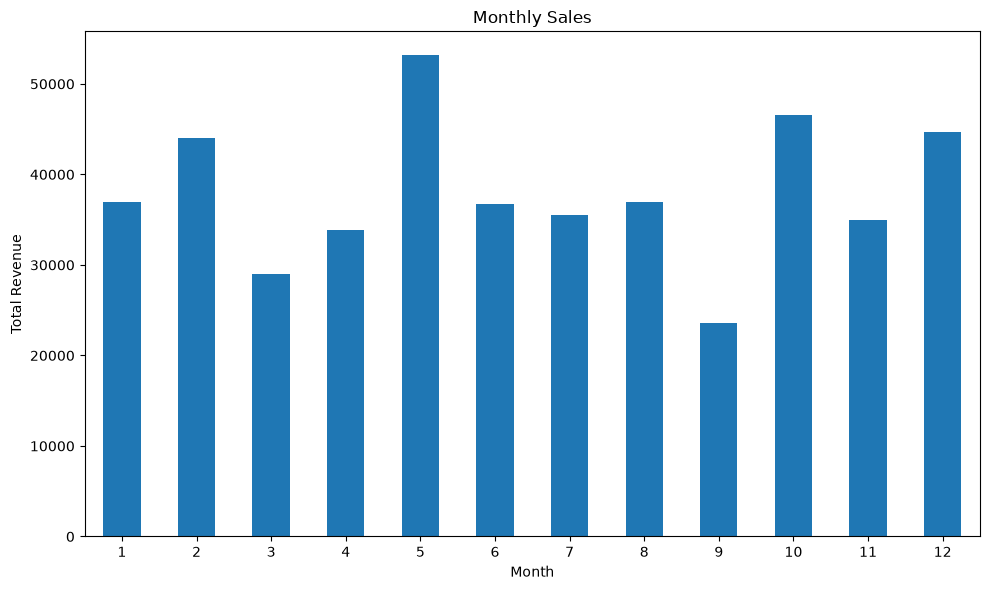

In [33]:
plt.figure(figsize=(10,6))

monthly_sales.plot(kind='bar')

plt.title('Monthly Sales')
plt.xlabel('Month')
plt.ylabel('Total Revenue')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [34]:
df['Quarter'] = df['Date'].dt.quarter

In [35]:
quarterly_sales = df.groupby('Quarter')['Total Amount'].sum()

quarterly_sales

Quarter
1    110030
2    123735
3     96045
4    126190
Name: Total Amount, dtype: int64

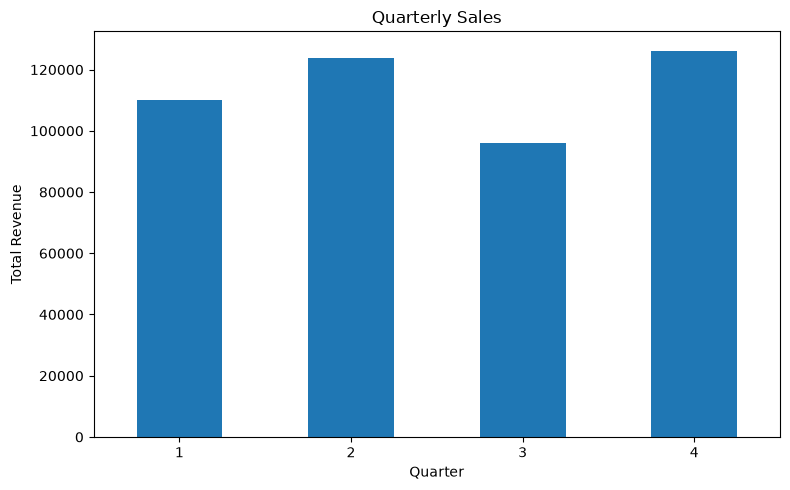

In [36]:
plt.figure(figsize=(8,5))

quarterly_sales.plot(kind='bar')

plt.title('Quarterly Sales')
plt.xlabel('Quarter')
plt.ylabel('Total Revenue')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [37]:
bins = [17, 25, 35, 45, 55, 100]
labels = ['18-25', '26-35', '36-45', '46-55', '56+']

df['Age Group'] = pd.cut(
    df['Age'],
    bins=bins,
    labels=labels
)

In [38]:
age_sales = df.groupby(
    'Age Group',
    observed=False
)['Total Amount'].sum()

age_sales

Age Group
18-25     84550
26-35     98480
36-45     91870
46-55    100690
56+       80410
Name: Total Amount, dtype: int64

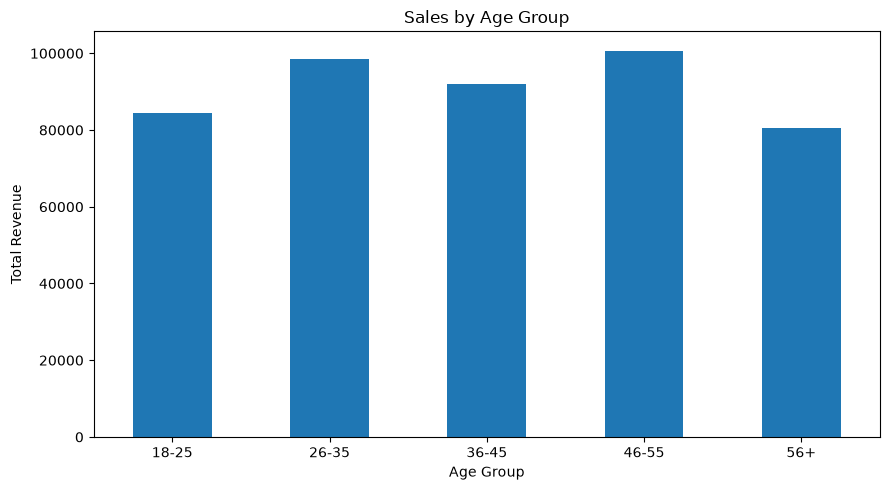

In [39]:
plt.figure(figsize=(9,5))

age_sales.plot(kind='bar')

plt.title('Sales by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Total Revenue')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [40]:
gender_sales = df.groupby('Gender')['Total Amount'].sum()

gender_sales

Gender
Female    232840
Male      223160
Name: Total Amount, dtype: int64

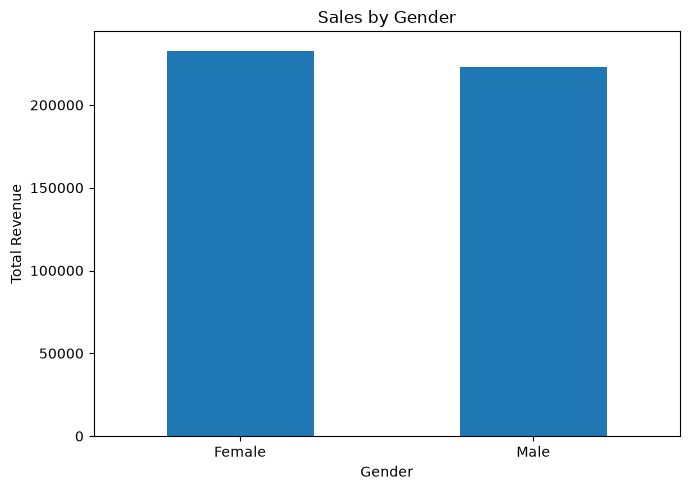

In [41]:
plt.figure(figsize=(7,5))

gender_sales.plot(kind='bar')

plt.title('Sales by Gender')
plt.xlabel('Gender')
plt.ylabel('Total Revenue')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [42]:
gender_count = df['Gender'].value_counts()

gender_count

Gender
Female    510
Male      490
Name: count, dtype: int64

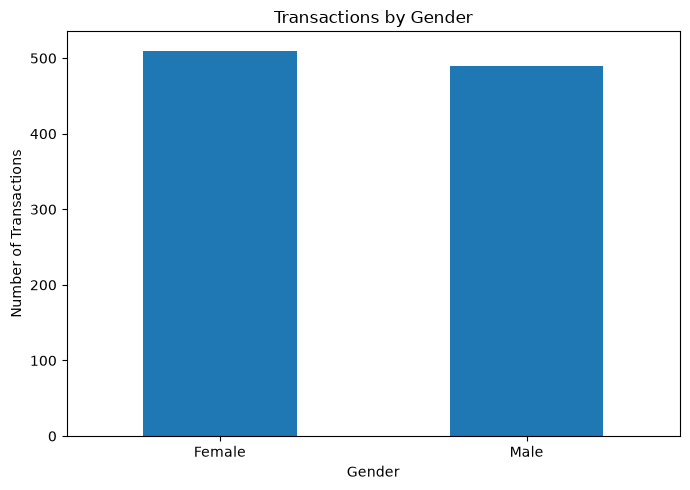

In [43]:
plt.figure(figsize=(7,5))

gender_count.plot(kind='bar')

plt.title('Transactions by Gender')
plt.xlabel('Gender')
plt.ylabel('Number of Transactions')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [44]:
category_sales = (
    df.groupby('Product Category')['Total Amount']
      .sum()
      .sort_values(ascending=False)
)

category_sales

Product Category
Electronics    156905
Clothing       155580
Beauty         143515
Name: Total Amount, dtype: int64

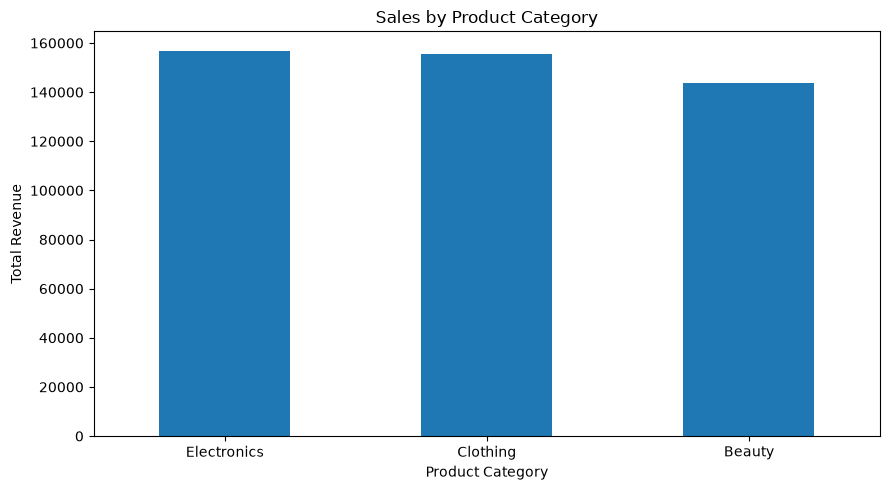

In [46]:
plt.figure(figsize=(9,5))

category_sales.plot(kind='bar')

plt.title('Sales by Product Category')
plt.xlabel('Product Category')
plt.ylabel('Total Revenue')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [47]:
category_quantity = (
    df.groupby('Product Category')['Quantity']
      .sum()
      .sort_values(ascending=False)
)

category_quantity

Product Category
Clothing       894
Electronics    849
Beauty         771
Name: Quantity, dtype: int64

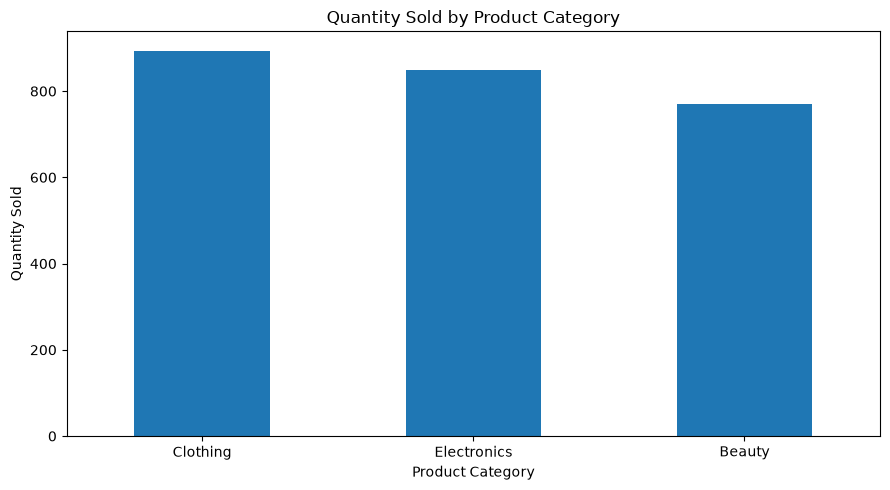

In [48]:
plt.figure(figsize=(9,5))

category_quantity.plot(kind='bar')

plt.title('Quantity Sold by Product Category')
plt.xlabel('Product Category')
plt.ylabel('Quantity Sold')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [49]:
correlation = df[
    ['Age', 'Quantity', 'Price per Unit', 'Total Amount']
].corr()

correlation

,Age,Quantity,Price per Unit,Total Amount
Age,1.000000,-0.023737,-0.038423,-0.060568
Quantity,-0.023737,1.000000,0.017501,0.373707
Price per Unit,-0.038423,0.017501,1.000000,0.851925
Total Amount,-0.060568,0.373707,0.851925,1.000000


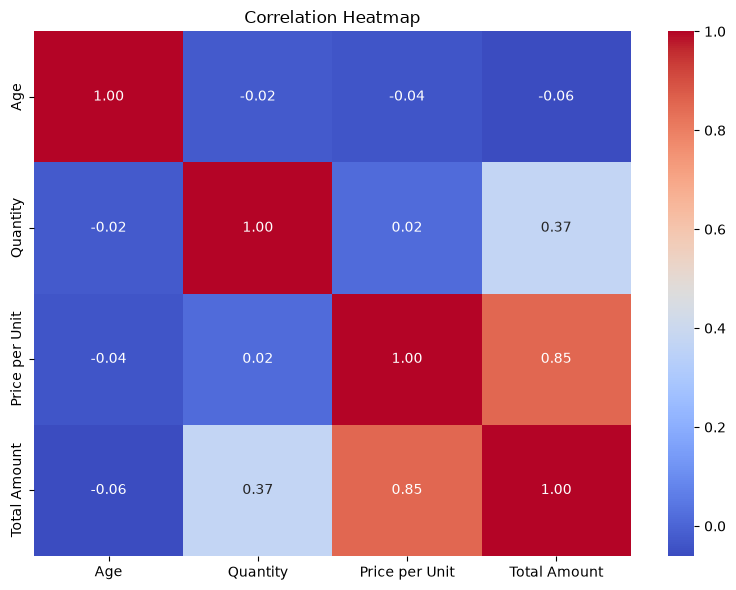

In [50]:
plt.figure(figsize=(8,6))

sns.heatmap(
    correlation,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

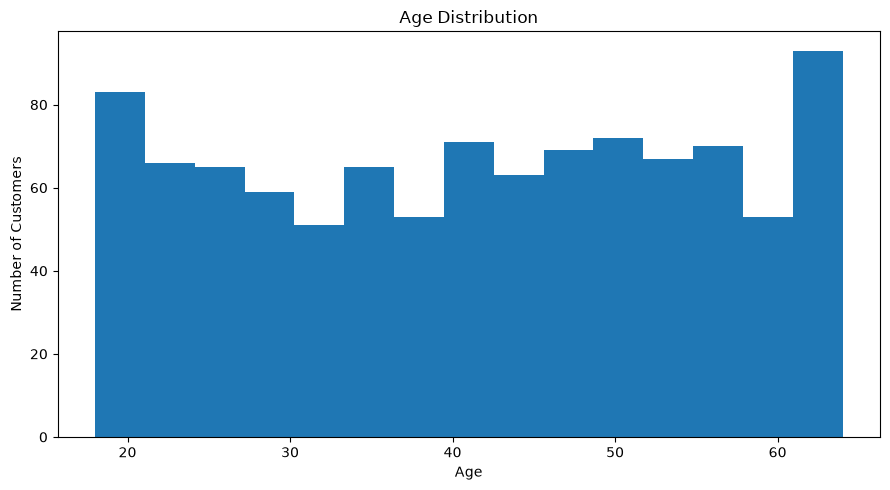

In [51]:
plt.figure(figsize=(9,5))

plt.hist(df['Age'], bins=15)

plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Number of Customers')

plt.tight_layout()
plt.show()

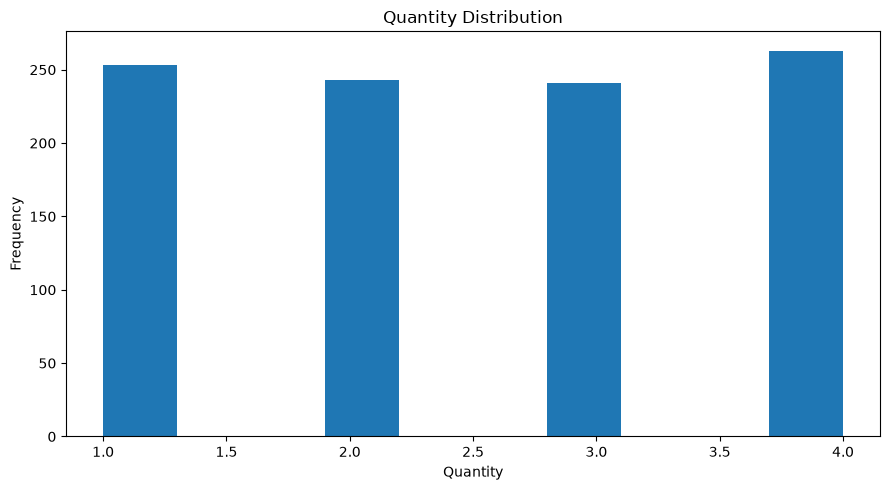

In [52]:
plt.figure(figsize=(9,5))

plt.hist(df['Quantity'], bins=10)

plt.title('Quantity Distribution')
plt.xlabel('Quantity')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

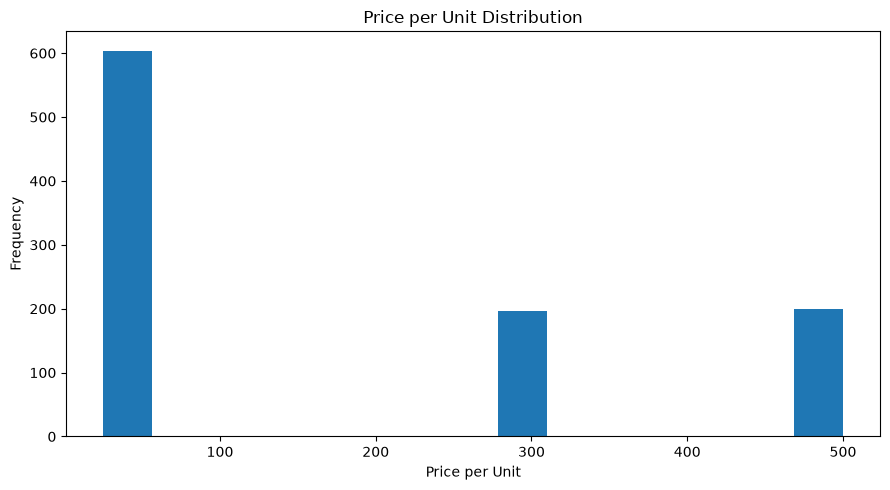

In [53]:
plt.figure(figsize=(9,5))

plt.hist(df['Price per Unit'], bins=15)

plt.title('Price per Unit Distribution')
plt.xlabel('Price per Unit')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

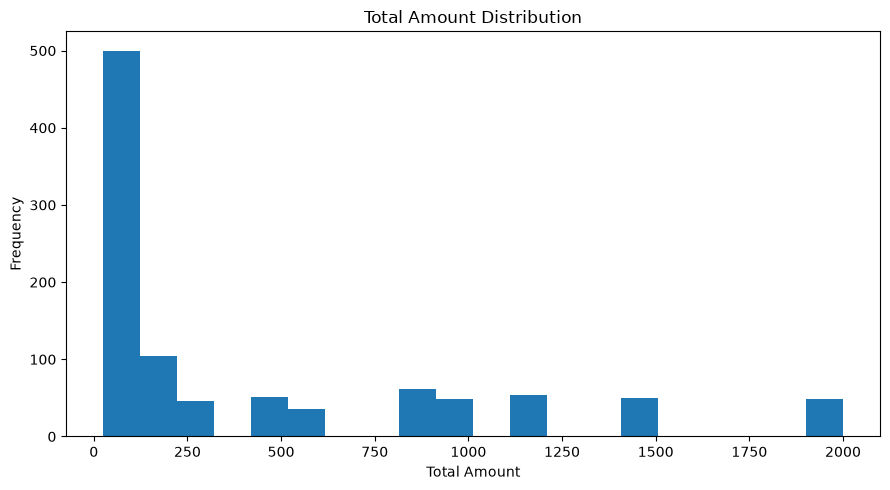

In [54]:
plt.figure(figsize=(9,5))

plt.hist(df['Total Amount'], bins=20)

plt.title('Total Amount Distribution')
plt.xlabel('Total Amount')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

In [55]:
print("========== KEY FINDINGS ==========")

print("Highest Revenue Category:",
      category_sales.idxmax())

print("Highest Revenue Category Sales:",
      category_sales.max())

print("Best Sales Month:",
      monthly_sales.idxmax())

print("Best Monthly Revenue:",
      monthly_sales.max())

print("Highest Revenue Age Group:",
      age_sales.idxmax())

print("Highest Revenue Gender:",
      gender_sales.idxmax())

print("Average Transaction Value:",
      round(df['Total Amount'].mean(), 2))

========== KEY FINDINGS ==========
Highest Revenue Category: Electronics
Highest Revenue Category Sales: 156905
Best Sales Month: 5
Best Monthly Revenue: 53150
Highest Revenue Age Group: 46-55
Highest Revenue Gender: Female
Average Transaction Value: 456.0


In [56]:
##Business Recommendations

1. **Focus on high-performing product categories:**
   Categories generating higher revenue can receive greater attention in marketing, promotions, and inventory planning.

2. Monitor monthly and quarterly sales trends:**
   Identifying stronger and weaker periods can help the business plan promotions and inventory according to demand.

3. Understand customer segments:**
   Age-group and gender analysis can help businesses understand which customer segments contribute more to revenue.

4. Optimize inventory based on quantity demand:**
   Categories with higher quantities sold should be monitored carefully to reduce the risk of stockouts.

5. Use data-driven marketing:
   Sales patterns across customer demographics and product categories can support more targeted marketing campaigns.

SyntaxError: invalid syntax (57665274.py, line 3)